In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [2]:
DATA_PATH = "Global_Superstore2.csv"

df = pd.read_csv(DATA_PATH, encoding="latin1", on_bad_lines="skip")

# Clean column names immediately (fixes columns like ' Order ID       ')
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (7766, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7766 entries, 0 to 7765
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          7766 non-null   int64  
 1   Order ID        7766 non-null   object 
 2   Order Date      7766 non-null   object 
 3   Ship Date       7766 non-null   object 
 4   Ship Mode       7766 non-null   object 
 5   Customer ID     7766 non-null   object 
 6   Customer Name   7766 non-null   object 
 7   Segment         7766 non-null   object 
 8   City            7766 non-null   object 
 9   State           7766 non-null   object 
 10  Country         7766 non-null   object 
 11  Postal Code     7766 non-null   int64  
 12  Market          7766 non-null   object 
 13  Region          7766 non-null   object 
 14  Product ID      7766 non-null   object 
 15  Category        7766 non-null   object 
 16  Sub-Category    7766 non-null   object 
 17  Product Name   

In [4]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("Missing values per column:")
print(df.isnull().sum())

Duplicate rows: 0

Missing values per column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Postal Code       0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64


In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wi...,2309.650,7,0.0,762.1845,933.57,Critical
1,40155,CA-2014-135909,14-10-2014,21-10-2014,Standard Class,JW-15220,Jane Waco,Corporate,Sacramento,California,...,OFF-BI-10003527,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bi...,5083.960,5,0.2,1906.4850,867.69,Low
2,40936,CA-2012-116638,28-01-2012,31-01-2012,Second Class,JH-15985,Joseph Holt,Consumer,Concord,North Carolina,...,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tab...,4297.644,13,0.4,-1862.3124,865.74,Critical
3,34577,CA-2011-102988,05-04-2011,09-04-2011,Second Class,GM-14695,Greg Maxwell,Corporate,Alexandria,Virginia,...,OFF-SU-10002881,Office Supplies,Supplies,Martin Yale Chadless Opener Electric Letter O...,4164.050,5,0.0,83.2810,846.54,High
4,36178,CA-2014-143567,03-11-2014,06-11-2014,Second Class,TB-21175,Thomas Boland,Corporate,Henderson,Kentucky,...,TEC-AC-10004145,Technology,Accessories,Logitech diNovo Edge Keyboard ...,2249.910,9,0.0,517.4793,780.70,Critical


In [6]:
def standardize_columns(data):
    """Standardize column names: strip, lowercase, replace spaces/dashes with underscores."""
    data = data.copy()
    data.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in data.columns]
    return data


def auto_detect_dates(data):
    """Try to parse object columns that look like dates."""
    data = data.copy()
    for col in data.select_dtypes(include="object").columns:
        try:
            converted = pd.to_datetime(data[col], errors="coerce")
            if converted.notna().sum() / len(data) > 0.7:
                data[col] = converted
        except Exception:
            pass
    return data


def handle_missing_values(data, strategy="none"):
    """
    Handle missing values for all column types.
    strategy: 'none', 'drop_rows', 'drop_high_missing_cols', 'fill_mean', 'fill_median', 'fill_mode'
    """
    data = data.copy()

    if strategy == "none":
        pass

    elif strategy == "drop_rows":
        for col in data.select_dtypes(include="object").columns:
            if data[col].isnull().sum() / len(data) > 0.5:
                data = data.drop(columns=[col])
        data = data.dropna()

    elif strategy == "drop_high_missing_cols":
        threshold = 0.4
        for col in data.columns:
            if data[col].isnull().sum() / len(data) > threshold:
                data = data.drop(columns=[col])

    elif strategy == "fill_mean":
        for col in data.select_dtypes(include=np.number).columns:
            data[col] = data[col].fillna(data[col].mean())
        for col in data.select_dtypes(include="object").columns:
            if not data[col].mode().empty:
                data[col] = data[col].fillna(data[col].mode()[0])

    elif strategy == "fill_median":
        for col in data.select_dtypes(include=np.number).columns:
            data[col] = data[col].fillna(data[col].median())
        for col in data.select_dtypes(include="object").columns:
            if not data[col].mode().empty:
                data[col] = data[col].fillna(data[col].mode()[0])

    elif strategy == "fill_mode":
        for col in data.columns:
            if not data[col].mode().empty:
                data[col] = data[col].fillna(data[col].mode()[0])

    return data


def detect_outliers_iqr(data):
    """Return a dict mapping numeric column names to outlier counts using the IQR method."""
    outlier_info = {}
    for col in data.select_dtypes(include=np.number).columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_info[col] = int(((data[col] < lower) | (data[col] > upper)).sum())
    return outlier_info


def get_dataset_summary(data):
    """Return a dict of basic summary info about the dataset."""
    return {
        "rows": len(data),
        "columns": len(data.columns),
        "numeric_cols": list(data.select_dtypes(include=np.number).columns),
        "categorical_cols": list(data.select_dtypes(include="object").columns),
        "date_cols": list(data.select_dtypes(include=["datetime64[ns]"]).columns),
        "missing_values": data.isnull().sum().to_dict(),
        "dtypes": data.dtypes.astype(str).to_dict(),
        "duplicates": int(data.duplicated().sum()),
    }

In [7]:
# Demo: dataset summary and outlier counts (read-only checks, df itself is left untouched
# here since the rest of the notebook relies on the original spaced-out column names like
# "Order Date", "Sub-Category", etc.)
summary = get_dataset_summary(df)
print("Rows:", summary["rows"], "| Columns:", summary["columns"])
print("Numeric columns:", summary["numeric_cols"])
print()
outliers = detect_outliers_iqr(df)
print("Outlier counts (IQR method):")
for col, count in outliers.items():
    print(f"  {col}: {count}")

Rows: 7766 | Columns: 24
Numeric columns: ['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']

Outlier counts (IQR method):
  Row ID: 0
  Postal Code: 0
  Sales: 928
  Quantity: 128
  Discount: 650
  Profit: 1464
  Shipping Cost: 982


In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter

# Keep month order chronological (Jan -> Dec) instead of alphabetical for charts/groupbys
MONTH_ORDER = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
df["Month"] = pd.Categorical(df["Month"], categories=MONTH_ORDER, ordered=True)

df["Profit Margin"] = (df["Profit"] / df["Sales"]) * 100

df.head()

C:\Users\nj181\AppData\Local\Temp\ipykernel_18740\1905876425.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order Date"] = pd.to_datetime(df["Order Date"])
C:\Users\nj181\AppData\Local\Temp\ipykernel_18740\1905876425.py:2: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Ship Date"] = pd.to_datetime(df["Ship Date"])


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Year,Month,Quarter,Profit Margin
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,2309.650,7,0.0,762.1845,933.57,Critical,2012,July,3,33.000000
1,40155,CA-2014-135909,2014-10-14,2014-10-21,Standard Class,JW-15220,Jane Waco,Corporate,Sacramento,California,...,5083.960,5,0.2,1906.4850,867.69,Low,2014,October,4,37.500000
2,40936,CA-2012-116638,2012-01-28,2012-01-31,Second Class,JH-15985,Joseph Holt,Consumer,Concord,North Carolina,...,4297.644,13,0.4,-1862.3124,865.74,Critical,2012,January,1,-43.333333
3,34577,CA-2011-102988,2011-04-05,2011-04-09,Second Class,GM-14695,Greg Maxwell,Corporate,Alexandria,Virginia,...,4164.050,5,0.0,83.2810,846.54,High,2011,April,2,2.000000
4,36178,CA-2014-143567,2014-11-03,2014-11-06,Second Class,TB-21175,Thomas Boland,Corporate,Henderson,Kentucky,...,2249.910,9,0.0,517.4793,780.70,Critical,2014,November,4,23.000000


In [9]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print(f"Total Sales:  ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")

Total Sales:  $1,912,928.40
Total Profit: $249,714.29


In [10]:
monthly_sales = df.groupby("Month", observed=True)["Sales"].sum()
yearly_sales = df.groupby("Year")["Sales"].sum()
quarterly_sales = df.groupby("Quarter")["Sales"].sum()

print("Monthly sales:\n", monthly_sales, "\n")
print("Yearly sales:\n", yearly_sales, "\n")
print("Quarterly sales:\n", quarterly_sales)

Monthly sales:
 Month
January       82976.5406
February      49533.4360
March        172006.0720
April        113018.3054
May          134998.0150
June         118187.4012
July         123251.5010
August       140294.3552
September    250184.1051
October      162687.9567
November     285086.5228
December     280704.1935
Name: Sales, dtype: float64 

Yearly sales:
 Year
2011    417112.9730
2012    383476.7346
2013    498133.1756
2014    614205.5213
Name: Sales, dtype: float64 

Quarterly sales:
 Quarter
1    304516.0486
2    366203.7216
3    513729.9613
4    728478.6730
Name: Sales, dtype: float64


In [11]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
market_profit = df.groupby("Market")["Profit"].sum().sort_values(ascending=False)

print("Profit by region:\n", region_profit, "\n")
print("Profit by market:\n", market_profit)

Profit by region:
 Region
West              93462.9439
East              79388.9560
South             38749.1620
Central           38113.2241
Name: Profit, dtype: float64 

Profit by market:
 Market
US        249714.286
Name: Profit, dtype: float64


In [12]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

print("Sales by category:\n", category_sales, "\n")
print("Sales by sub-category:\n", subcategory_sales)

Sales by category:
 Category
Technology         807395.5350
Office Supplies    588439.1490
Furniture          517093.7205
Name: Sales, dtype: float64 

Sales by sub-category:
 Sub-Category
Phones          324174.2360
Chairs          249227.3410
Binders         191893.7680
Machines        170446.8830
Accessories     163246.3860
Tables          160340.8415
Storage         153565.6640
Copiers         149528.0300
Appliances       89536.1010
Paper            68139.3120
Furnishings      58474.8700
Bookcases        49050.6680
Supplies         45952.4700
Art              19076.5280
Envelopes        10744.4080
Labels            7478.2720
Fasteners         2052.6260
Name: Sales, dtype: float64


In [13]:
top10_products_sales = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
bottom10_products_profit = df.groupby("Product Name")["Profit"].sum().sort_values().head(10)

print("Top 10 products by sales:\n", top10_products_sales, "\n")
print("Bottom 10 products by profit:\n", bottom10_products_profit)

Top 10 products by sales:
 Product Name
Canon imageCLASS 2200 Advanced Copier                                                                                                61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind                                                          27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                                                                                22638.480
HON 5400 Series Task Chairs for Big and Tall                                                                                         21870.576
GBC DocuBind TL300 Electric Binding System                                                                                           19823.479
GBC Ibimaster 500 Manual ProClick Binding System                                                                                     19024.500
Hewlett Packard LaserJet 3310 Copier                                                                  

In [14]:
top10_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
country_sales = df.groupby("Country")["Sales"].sum().sort_values(ascending=False).head(10)

print("Top 10 customers:\n", top10_customers, "\n")
print("Sales by segment:\n", segment_sales, "\n")
print("Top 10 countries by sales:\n", country_sales)

Top 10 customers:
 Customer Name
Sean Miller               24257.626
Tamara Chand              19017.848
Raymond Buch              15117.339
Tom Ashbrook              14595.620
Ken Lonsdale              13940.717
Sanjit Chand              13701.674
Adrian Barton             13448.947
Hunter Lopez              12799.908
Sanjit Engle              11915.628
Christopher Conant        11841.104
Name: Sales, dtype: float64 

Sales by segment:
 Segment
Consumer       978955.8288
Corporate      568651.1884
Home Office    365321.3873
Name: Sales, dtype: float64 

Top 10 countries by sales:
 Country
United States                       1.912928e+06
Name: Sales, dtype: float64


In [15]:
ship_mode_sales = df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False)
shipping_cost_market = df.groupby("Market")["Shipping Cost"].sum().sort_values(ascending=False)
order_priority_sales = df.groupby("Order Priority")["Sales"].sum().sort_values(ascending=False)

print("Sales by ship mode:\n", ship_mode_sales, "\n")
print("Shipping cost by market:\n", shipping_cost_market, "\n")
print("Sales by order priority:\n", order_priority_sales)

Sales by ship mode:
 Ship Mode
Standard Class    1.119194e+06
Second Class      3.810228e+05
First Class       3.028516e+05
Same Day          1.098600e+05
Name: Sales, dtype: float64 

Shipping cost by market:
 Market
US        198948.28
Name: Shipping Cost, dtype: float64 

Sales by order priority:
 Order Priority
Medium      1.103354e+06
High        5.874711e+05
Critical    1.515541e+05
Low         7.054880e+04
Name: Sales, dtype: float64


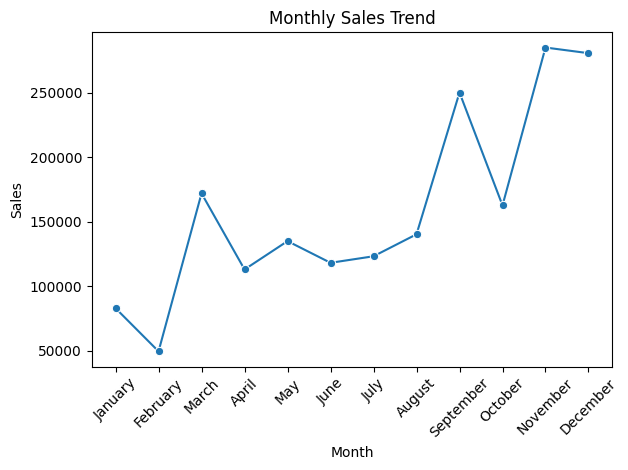

In [16]:
sns.lineplot(data=monthly_sales.reset_index(), x="Month", y="Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

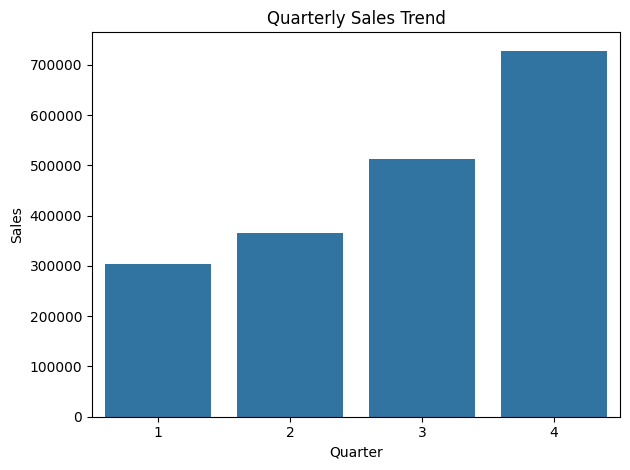

In [17]:
sns.barplot(data=quarterly_sales.reset_index(), x="Quarter", y="Sales")
plt.title("Quarterly Sales Trend")
plt.tight_layout()
plt.show()

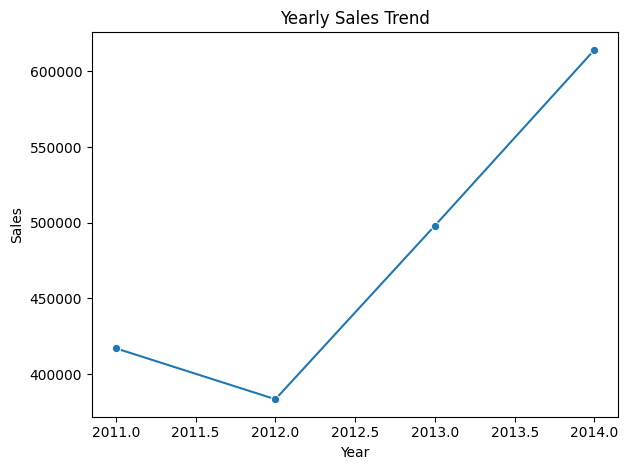

In [18]:
sns.lineplot(data=yearly_sales.reset_index(), x="Year", y="Sales", marker="o")
plt.title("Yearly Sales Trend")
plt.tight_layout()
plt.show()

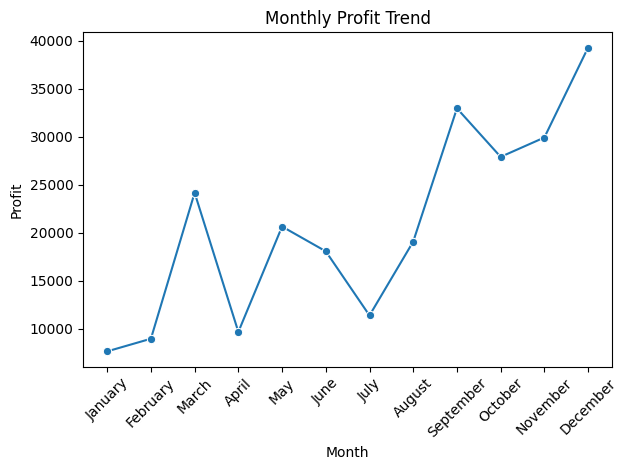

In [19]:
monthly_profit = df.groupby("Month", observed=True)["Profit"].sum().reset_index()
sns.lineplot(data=monthly_profit, x="Month", y="Profit", marker="o")
plt.title("Monthly Profit Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

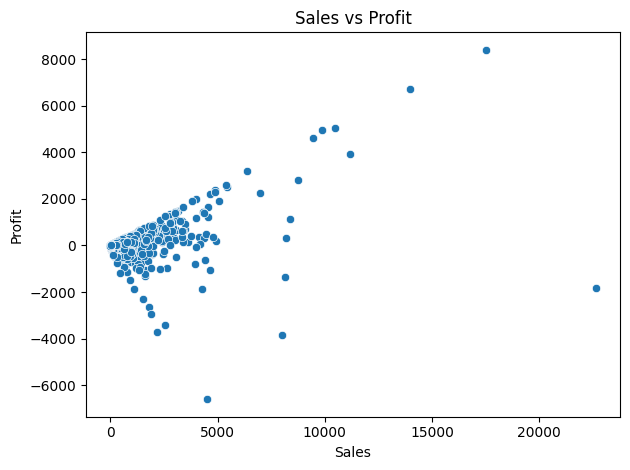

In [20]:
sns.scatterplot(data=df, x="Sales", y="Profit")
plt.title("Sales vs Profit")
plt.tight_layout()
plt.show()

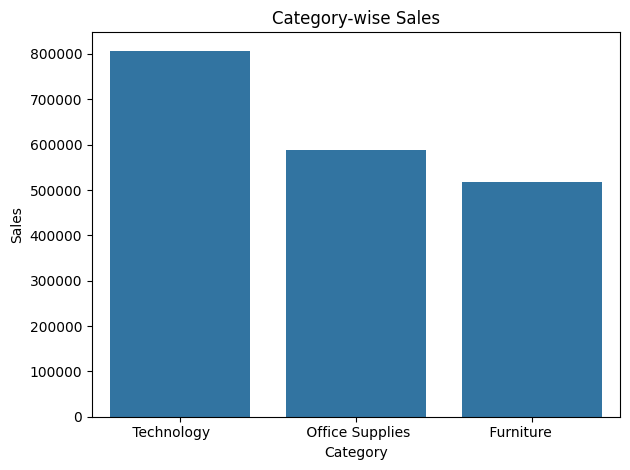

In [21]:
sns.barplot(data=category_sales.reset_index(), x="Category", y="Sales")
plt.title("Category-wise Sales")
plt.tight_layout()
plt.show()

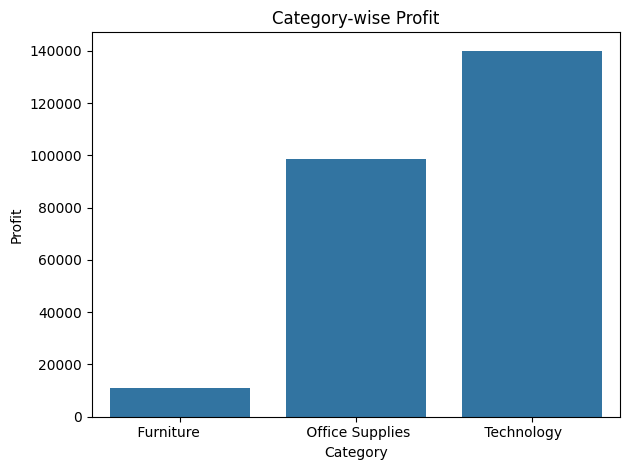

In [22]:
category_profit = df.groupby("Category")["Profit"].sum().reset_index()
sns.barplot(data=category_profit, x="Category", y="Profit")
plt.title("Category-wise Profit")
plt.tight_layout()
plt.show()

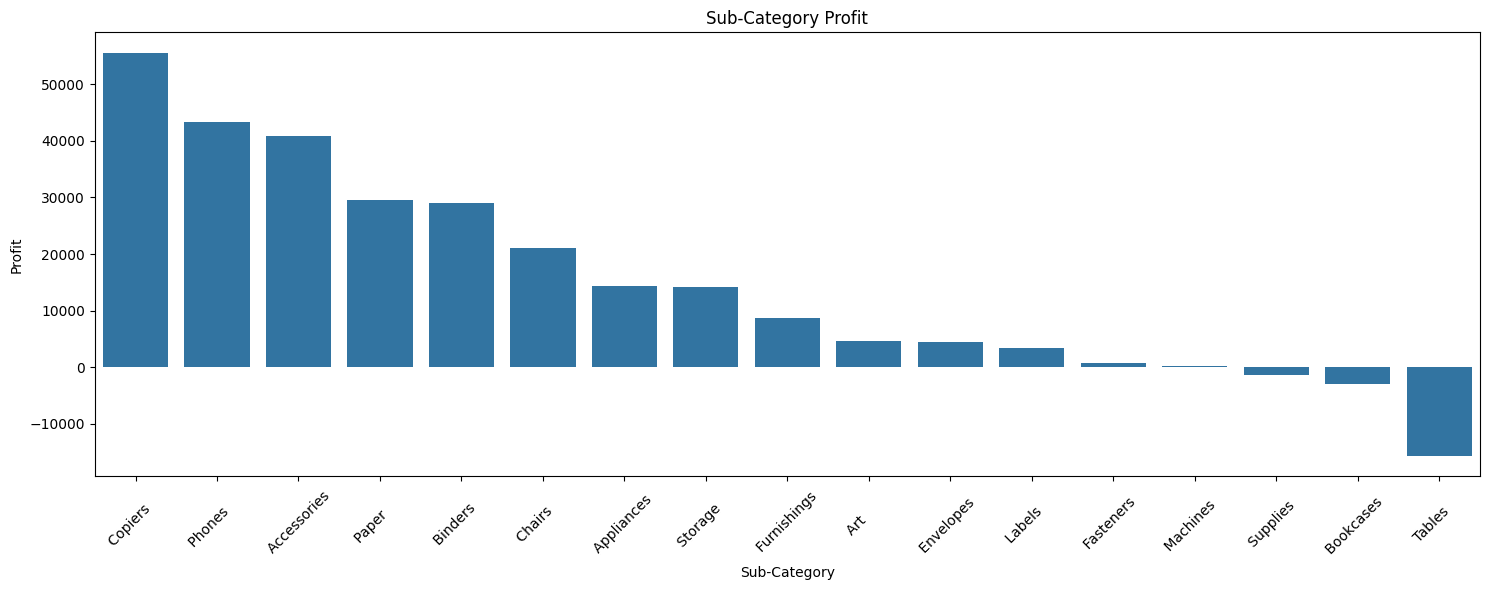

In [23]:
sub_profit = df.groupby("Sub-Category")["Profit"].sum().reset_index().sort_values("Profit", ascending=False)
plt.figure(figsize=(15, 6))
sns.barplot(data=sub_profit, x="Sub-Category", y="Profit")
plt.xticks(rotation=45)
plt.title("Sub-Category Profit")
plt.tight_layout()
plt.show()

C:\Users\nj181\AppData\Local\Temp\ipykernel_18740\2890407607.py:3: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


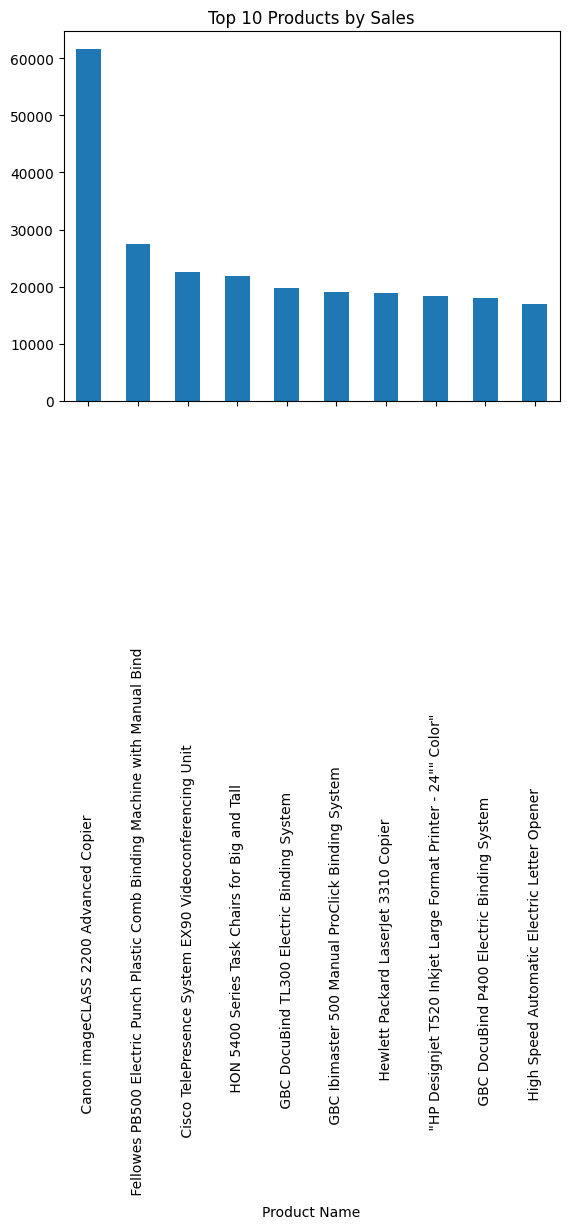

In [24]:
top10_products_sales.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.tight_layout()
plt.show()

C:\Users\nj181\AppData\Local\Temp\ipykernel_18740\1198923828.py:3: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


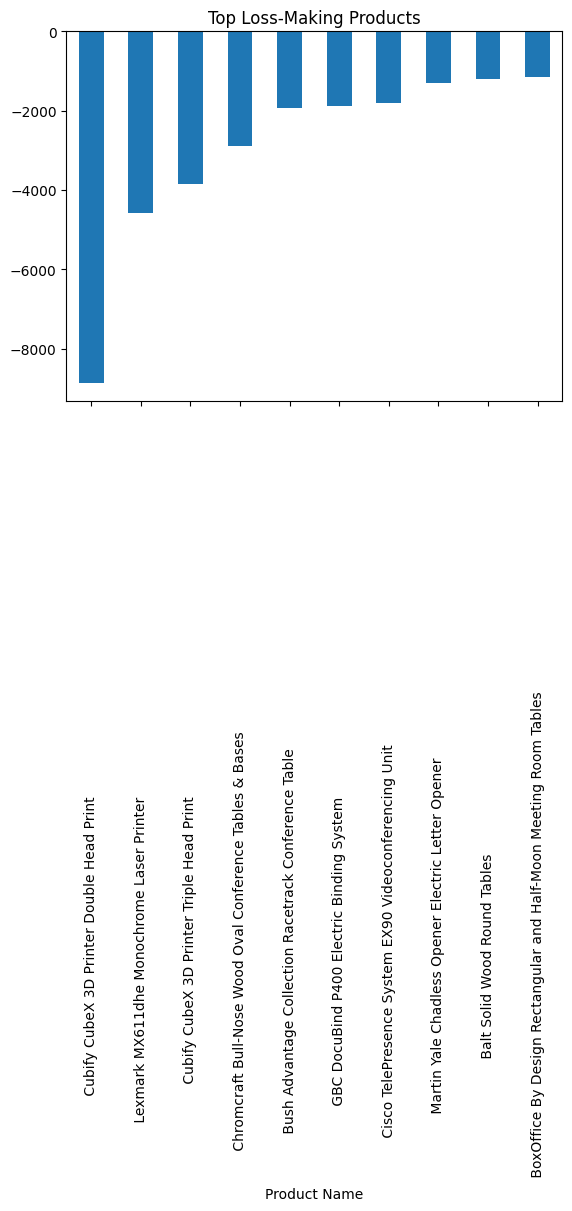

In [25]:
bottom10_products_profit.plot(kind="bar")
plt.title("Top Loss-Making Products")
plt.tight_layout()
plt.show()

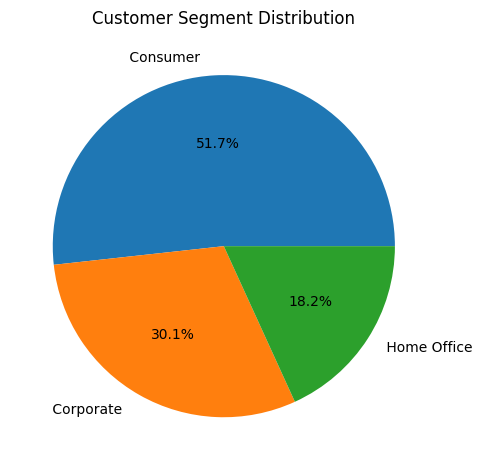

In [26]:
df["Segment"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Customer Segment Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

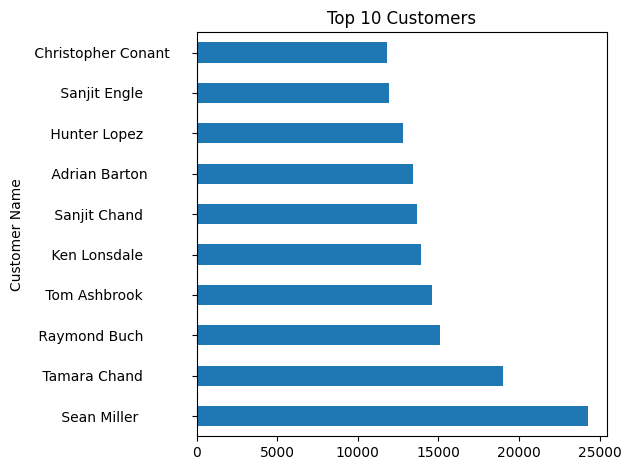

In [27]:
top10_customers.plot(kind="barh")
plt.title("Top 10 Customers")
plt.tight_layout()
plt.show()

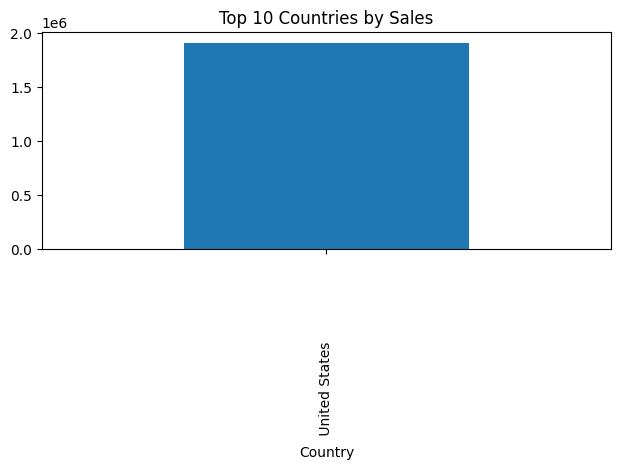

In [28]:
country_sales.plot(kind="bar")
plt.title("Top 10 Countries by Sales")
plt.tight_layout()
plt.show()

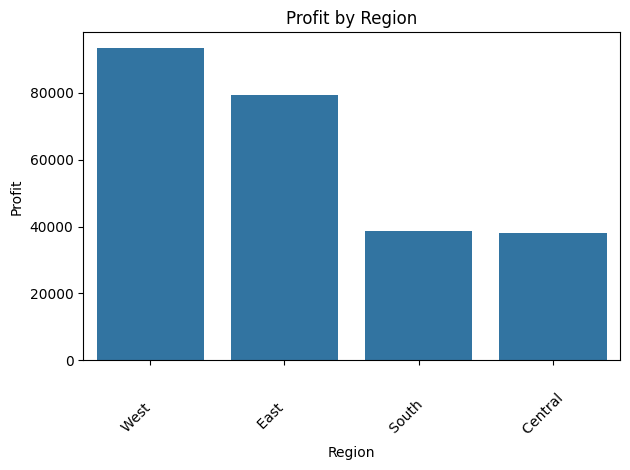

In [29]:
sns.barplot(data=region_profit.reset_index(), x="Region", y="Profit")
plt.xticks(rotation=45)
plt.title("Profit by Region")
plt.tight_layout()
plt.show()

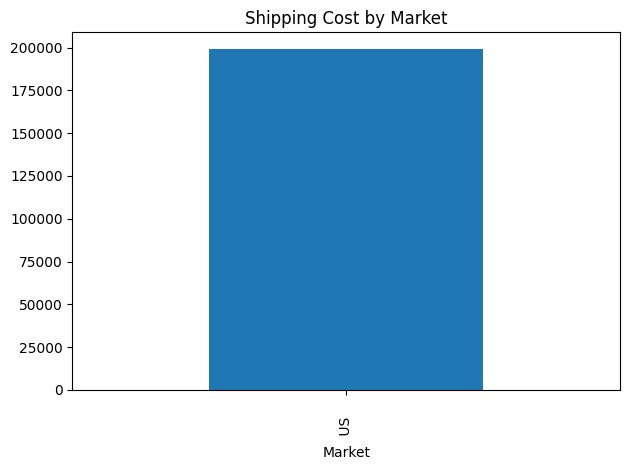

In [30]:
shipping_cost_market.plot(kind="bar")
plt.title("Shipping Cost by Market")
plt.tight_layout()
plt.show()

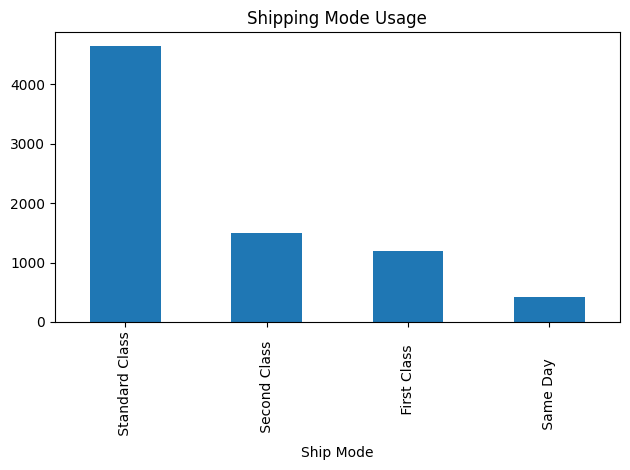

In [31]:
df["Ship Mode"].value_counts().plot(kind="bar")
plt.title("Shipping Mode Usage")
plt.tight_layout()
plt.show()

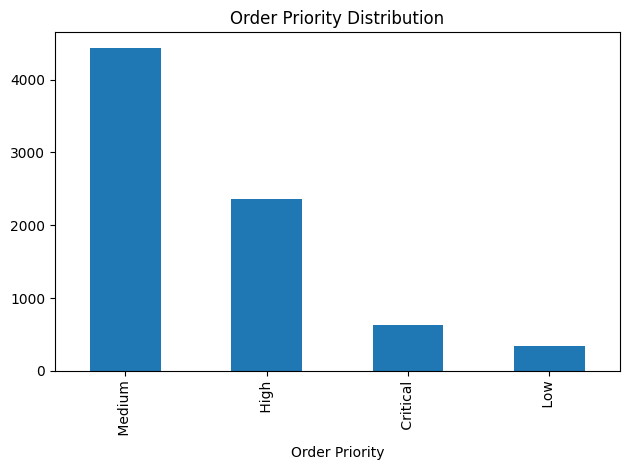

In [32]:
df["Order Priority"].value_counts().plot(kind="bar")
plt.title("Order Priority Distribution")
plt.tight_layout()
plt.show()

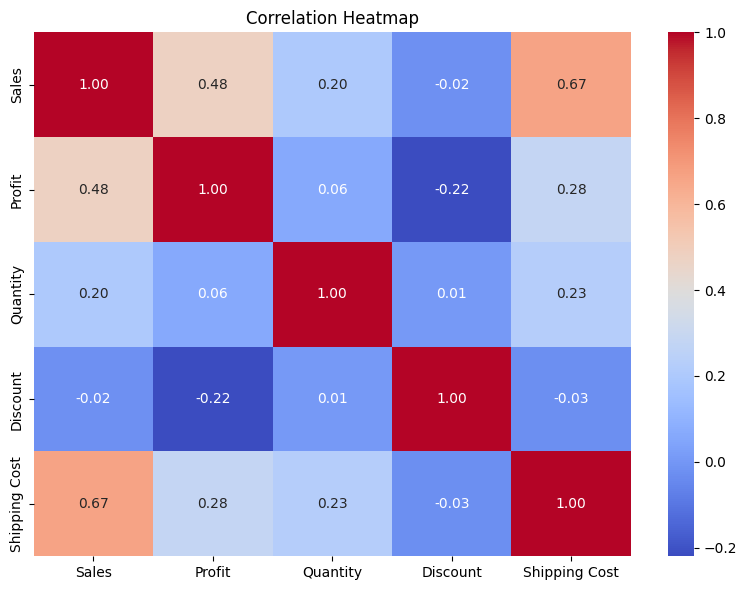

In [33]:
num_cols = ["Sales", "Profit", "Quantity", "Discount", "Shipping Cost"]
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

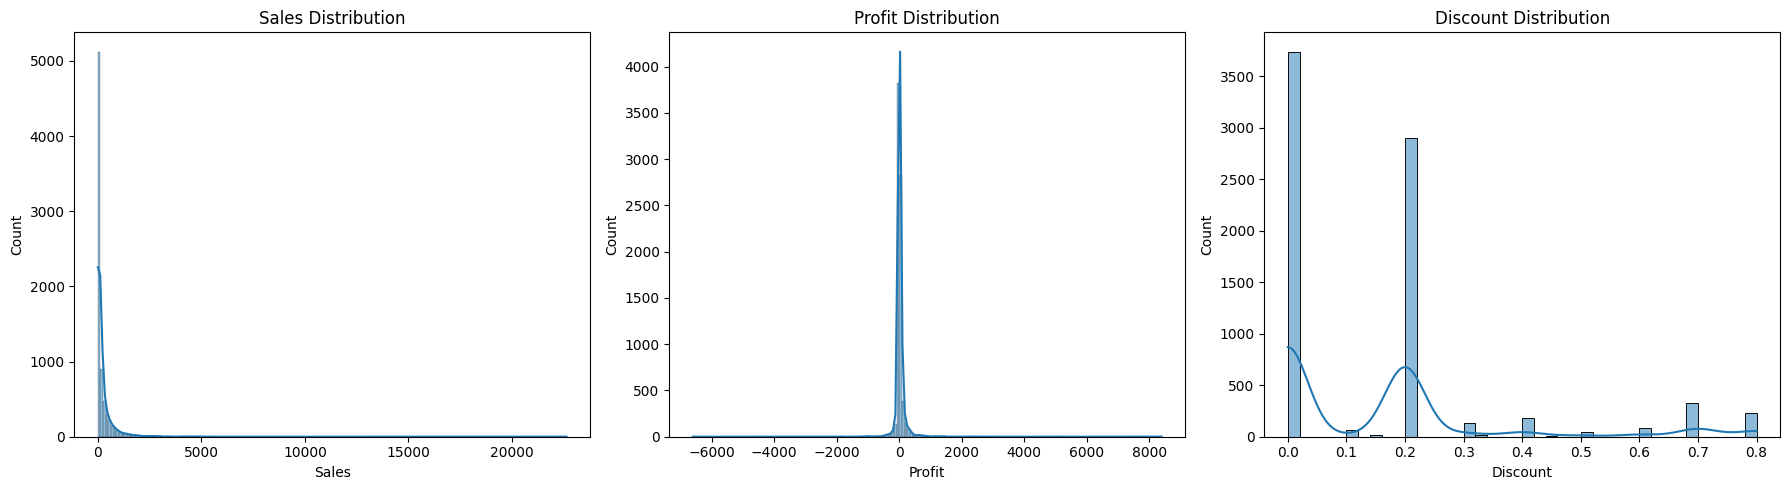

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df["Sales"], kde=True, ax=axes[0]).set_title("Sales Distribution")
sns.histplot(df["Profit"], kde=True, ax=axes[1]).set_title("Profit Distribution")
sns.histplot(df["Discount"], kde=True, ax=axes[2]).set_title("Discount Distribution")
plt.tight_layout()
plt.show()

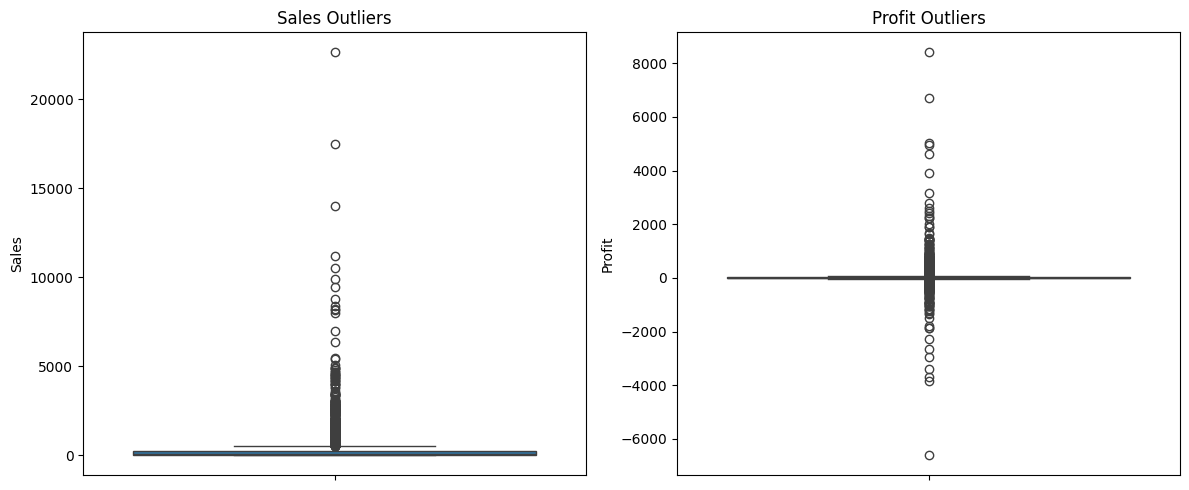

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df["Sales"], ax=axes[0]).set_title("Sales Outliers")
sns.boxplot(y=df["Profit"], ax=axes[1]).set_title("Profit Outliers")
plt.tight_layout()
plt.show()

In [36]:
print("=" * 70)
print("GLOBAL RETAIL INTELLIGENCE - BUSINESS INSIGHTS")
print("=" * 70)

insights = []

market_sales_sum = df.groupby("Market")["Sales"].sum()
insights.append(f"Highest Revenue Market: {market_sales_sum.idxmax()} (${market_sales_sum.max():,.2f})")

cat_profit_sum = df.groupby("Category")["Profit"].sum()
insights.append(f"Most Profitable Category: {cat_profit_sum.idxmax()} (${cat_profit_sum.max():,.2f})")

subcat_profit_sum = df.groupby("Sub-Category")["Profit"].sum()
insights.append(f"Least Profitable Sub-Category: {subcat_profit_sum.idxmin()} (${subcat_profit_sum.min():,.2f})")

cust_sales_sum = df.groupby("Customer Name")["Sales"].sum()
insights.append(f"Top Customer: {cust_sales_sum.idxmax()} (${cust_sales_sum.max():,.2f})")

top20_share = cust_sales_sum.sort_values(ascending=False).head(20).sum() / total_sales * 100
insights.append(f"Top 20 customers contribute {top20_share:.2f}% of total revenue")

insights.append(f"Most Preferred Shipping Mode: {df['Ship Mode'].value_counts().idxmax()}")

country_sales_sum = df.groupby("Country")["Sales"].sum()
insights.append(f"Highest Revenue Country: {country_sales_sum.idxmax()}")

region_profit_sum = df.groupby("Region")["Profit"].sum()
insights.append(f"Most Profitable Region: {region_profit_sum.idxmax()}")

insights.append(f"Average Discount Offered: {df['Discount'].mean():.2%}")

ship_cost_sum = df.groupby("Market")["Shipping Cost"].sum()
insights.append(f"Highest Shipping Cost Market: {ship_cost_sum.idxmax()}")

prod_sales_sum = df.groupby("Product Name")["Sales"].sum()
insights.append(f"Best-Selling Product: {prod_sales_sum.idxmax()}")

prod_profit_sum = df.groupby("Product Name")["Profit"].sum()
insights.append(f"Highest Loss-Making Product: {prod_profit_sum.idxmin()}")

for i, insight in enumerate(insights, start=1):
    print(f"{i}. {insight}")

print("=" * 70)

GLOBAL RETAIL INTELLIGENCE - BUSINESS INSIGHTS
1. Highest Revenue Market:  US     ($1,912,928.40)
2. Most Profitable Category:  Technology      ($140,072.94)
3. Least Profitable Sub-Category:  Tables       ($-15,714.46)
4. Top Customer:  Sean Miller            ($24,257.63)
5. Top 20 customers contribute 13.00% of total revenue
6. Most Preferred Shipping Mode:  Standard Class
7. Highest Revenue Country:  United States                   
8. Most Profitable Region:  West          
9. Average Discount Offered: 15.53%
10. Highest Shipping Cost Market:  US    
11. Best-Selling Product:  Canon imageCLASS 2200 Advanced Copier                                                                                            
12. Highest Loss-Making Product:  Cubify CubeX 3D Printer Double Head Print                                                                                        


In [37]:
kpi_total_sales = df["Sales"].sum()
kpi_total_profit = df["Profit"].sum()
kpi_total_orders = df["Order ID"].nunique()
kpi_total_customers = df["Customer ID"].nunique()
kpi_avg_discount = df["Discount"].mean()

gria_summary = {
    "Total Sales": kpi_total_sales,
    "Total Profit": kpi_total_profit,
    "Total Orders": kpi_total_orders,
    "Total Customers": kpi_total_customers,
    "Average Discount": kpi_avg_discount,
}

gria_summary

{'Total Sales': np.float64(1912928.4045000002),
 'Total Profit': np.float64(249714.286),
 'Total Orders': 4344,
 'Total Customers': 792,
 'Average Discount': np.float64(0.15533608035024468)}

In [38]:

%pip install -q groq python-dotenv

import os
from dotenv import load_dotenv
from groq import Groq

load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

client = Groq(api_key=GROQ_API_KEY) if GROQ_API_KEY else None

if client is None:
    print("GROQ_API_KEY not found. Set it in a .env file to enable the Chat With Data feature.")
else:
    print("Groq client initialized.")

Note: you may need to restart the kernel to use updated packages.
Groq client initialized.


In [39]:
dataset_context = f"""
GLOBAL SUPERSTORE DATASET

Rows: {df.shape[0]}
Columns: {list(df.columns)}

Total Sales: {df['Sales'].sum():,.2f}
Total Profit: {df['Profit'].sum():,.2f}
Total Orders: {df['Order ID'].nunique()}
Total Customers: {df['Customer ID'].nunique()}

Markets: {df['Market'].unique().tolist()}
Categories: {df['Category'].unique().tolist()}
Segments: {df['Segment'].unique().tolist()}

Highest Revenue Market: {df.groupby('Market')['Sales'].sum().idxmax()}
Most Profitable Category: {df.groupby('Category')['Profit'].sum().idxmax()}
Top Customer: {df.groupby('Customer Name')['Sales'].sum().idxmax()}
Loss Making Sub-Category: {df.groupby('Sub-Category')['Profit'].sum().idxmin()}
"""

print(dataset_context)


GLOBAL SUPERSTORE DATASET

Rows: 7766
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority', 'Year', 'Month', 'Quarter', 'Profit Margin']

Total Sales: 1,912,928.40
Total Profit: 249,714.29
Total Orders: 4344
Total Customers: 792

Markets: [' US    ']
Categories: [' Technology     ', ' Office Supplies', ' Furniture      ']
Segments: [' Consumer   ', ' Corporate  ', ' Home Office']

Highest Revenue Market:  US    
Most Profitable Category:  Technology     
Top Customer:  Sean Miller           
Loss Making Sub-Category:  Tables      



In [40]:
SYSTEM_PROMPT = """
You are GRIA (Global Retail Intelligence Assistant).

You are an expert in retail analytics, customer analytics, product analytics,
supply chain analytics, and business intelligence.

Always provide:
1. Direct Answer
2. Key Findings
3. Business Impact
4. Recommendation

Never mention that you are an AI model.
"""


def ask_gria(question, context=dataset_context):
    """Ask a natural-language business question about the dataset using Groq's LLM."""
    if client is None:
        return "Groq API Key not configured. Add GROQ_API_KEY to your .env file."

    prompt = f"""
    Dataset Context:
    {context}

    User Question:
    {question}

    Provide:
    1. Direct Answer
    2. Key Findings
    3. Business Impact
    4. Recommendation
    """

    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": prompt},
            ],
            temperature=0.2,
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Error: {str(e)}"

In [41]:
from dotenv import load_dotenv
import os

load_dotenv()

print(os.getenv("GROQ_API_KEY"))

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


In [42]:
%%writefile GRIA_app.py

import os
import pandas as pd
import streamlit as st
import plotly.express as px
from dotenv import load_dotenv
from groq import Groq

# ==================================================
# PAGE CONFIGURATION
# ==================================================

st.set_page_config(
    page_title="Global Retail Intelligence Assistant",
    page_icon="\U0001F4CA",
    layout="wide"
)

MONTH_ORDER = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

# ==================================================
# LOAD DATA
# ==================================================

@st.cache_data
def load_data():
    data = pd.read_csv(
        "Global_Superstore2.csv",
        encoding="latin1",
        engine="python",
        on_bad_lines="skip"
    )

    data.columns = data.columns.str.strip()

    data["Order Date"] = pd.to_datetime(data["Order Date"])
    data["Ship Date"] = pd.to_datetime(data["Ship Date"])

    data["Year"] = data["Order Date"].dt.year
    data["Month"] = data["Order Date"].dt.month_name()
    data["Month"] = pd.Categorical(data["Month"], categories=MONTH_ORDER, ordered=True)
    data["Quarter"] = data["Order Date"].dt.quarter

    return data


df = load_data()

# ==================================================
# TITLE
# ==================================================

st.title("\U0001F4CA Global Retail Intelligence Assistant (GRIA)")

# ==================================================
# GROQ AI ASSISTANT
# ==================================================

load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
client = Groq(api_key=GROQ_API_KEY) if GROQ_API_KEY else None

SYSTEM_PROMPT = """
You are GRIA (Global Retail Intelligence Assistant).

You are an expert in:
- Retail Analytics
- Customer Analytics
- Product Analytics
- Supply Chain Analytics
- Business Intelligence

Always provide:
1. Direct Answer
2. Key Findings
3. Business Impact
4. Recommendation

Never mention that you are an AI model.
"""


def ask_gria(question, data):
    if client is None:
        return "Groq API Key not configured."

    dataset_context = f"""
    GLOBAL SUPERSTORE DATASET

    Total Sales: {data['Sales'].sum():,.2f}
    Total Profit: {data['Profit'].sum():,.2f}
    Total Orders: {data['Order ID'].nunique()}
    Total Customers: {data['Customer ID'].nunique()}

    Markets: {', '.join(data['Market'].unique())}
    Categories: {', '.join(data['Category'].unique())}
    Segments: {', '.join(data['Segment'].unique())}

    Highest Revenue Market: {data.groupby('Market')['Sales'].sum().idxmax()}
    Most Profitable Category: {data.groupby('Category')['Profit'].sum().idxmax()}
    Highest Revenue Country: {data.groupby('Country')['Sales'].sum().idxmax()}
    Most Profitable Region: {data.groupby('Region')['Profit'].sum().idxmax()}
    """

    prompt = f"""
    Dataset Context:
    {dataset_context}

    User Question:
    {question}

    Provide:
    1. Direct Answer
    2. Key Findings
    3. Business Impact
    4. Recommendation
    """

    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": prompt},
            ],
            temperature=0.2,
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Error: {str(e)}"


sample_questions = [
    "Which market generates highest revenue?",
    "Which category is most profitable?",
    "Which products are causing losses?",
    "Who are the top customers?",
    "What is the best shipping mode?",
    "Give me 5 strategic recommendations.",
]

# ==================================================
# SIDEBAR FILTERS
# ==================================================

st.sidebar.header("Filters")

year = st.sidebar.multiselect("Year", sorted(df["Year"].unique()), default=sorted(df["Year"].unique()))
market = st.sidebar.multiselect("Market", sorted(df["Market"].unique()), default=sorted(df["Market"].unique()))
region = st.sidebar.multiselect("Region", sorted(df["Region"].unique()), default=sorted(df["Region"].unique()))

filtered_df = df[
    (df["Year"].isin(year))
    & (df["Market"].isin(market))
    & (df["Region"].isin(region))
]

if filtered_df.empty:
    st.warning("No data available for selected filters.")
    st.stop()

# ==================================================
# KPI SECTION
# ==================================================

sales = filtered_df["Sales"].sum()
profit = filtered_df["Profit"].sum()
orders = filtered_df["Order ID"].nunique()
customers = filtered_df["Customer ID"].nunique()
profit_margin = (profit / sales) * 100 if sales != 0 else 0

c1, c2, c3, c4, c5 = st.columns(5)
c1.metric("Sales", f"${sales:,.0f}")
c2.metric("Profit", f"${profit:,.0f}")
c3.metric("Orders", f"{orders:,}")
c4.metric("Customers", f"{customers:,}")
c5.metric("Margin", f"{profit_margin:.2f}%")

# ==================================================
# TABS
# ==================================================

tab1, tab2, tab3, tab4, tab5, tab6 = st.tabs(
    ["Sales", "Products", "Customers", "Geography", "Shipping", "Insights"]
)

with tab1:
    st.subheader("Monthly Sales Trend")
    monthly = filtered_df.groupby(["Year", "Month"], observed=True)["Sales"].sum().reset_index()
    fig = px.line(monthly, x="Month", y="Sales", color="Year", markers=True, title="Monthly Sales Trend")
    st.plotly_chart(fig, use_container_width=True)

with tab2:
    st.subheader("Category Sales")
    cat_sales = filtered_df.groupby("Category")["Sales"].sum().reset_index()
    fig = px.bar(cat_sales, x="Category", y="Sales", color="Category", title="Category Sales")
    st.plotly_chart(fig, use_container_width=True)

with tab3:
    st.subheader("Segment Distribution")
    seg = filtered_df.groupby("Segment")["Sales"].sum().reset_index()
    fig = px.pie(seg, names="Segment", values="Sales", title="Sales by Segment")
    st.plotly_chart(fig, use_container_width=True)

with tab4:
    st.subheader("Top 10 Countries by Sales")
    country = filtered_df.groupby("Country")["Sales"].sum().nlargest(10).reset_index()
    fig = px.bar(country, x="Country", y="Sales", title="Top 10 Countries by Sales")
    st.plotly_chart(fig, use_container_width=True)

with tab5:
    st.subheader("Shipping Cost by Market")
    ship = filtered_df.groupby("Market")["Shipping Cost"].sum().reset_index()
    fig = px.bar(ship, x="Market", y="Shipping Cost", title="Shipping Cost by Market")
    st.plotly_chart(fig, use_container_width=True)

with tab6:
    st.subheader("Business Insights")
    top_market = filtered_df.groupby("Market")["Sales"].sum().idxmax()
    top_category = filtered_df.groupby("Category")["Profit"].sum().idxmax()
    top_customer = filtered_df.groupby("Customer Name")["Sales"].sum().idxmax()
    top_country = filtered_df.groupby("Country")["Sales"].sum().idxmax()

    st.success(f"Highest Revenue Market: {top_market}")
    st.success(f"Most Profitable Category: {top_category}")
    st.success(f"Top Customer: {top_customer}")
    st.success(f"Highest Revenue Country: {top_country}")

    st.dataframe(filtered_df.head(20))

st.markdown("---")
st.subheader("\U0001F916 Chat With Data")

selected_question = st.selectbox("Choose a sample question", [""] + sample_questions)
user_question = st.text_input("Or type your own question", value=selected_question)

if st.button("Analyze Data"):
    if user_question.strip():
        with st.spinner("Analyzing business data..."):
            answer = ask_gria(user_question, filtered_df)
        st.markdown("### AI Analysis")
        st.write(answer)
    else:
        st.warning("Please enter a question.")

Overwriting GRIA_app.py


In [ ]:
!streamlit run GRIA_app.py